# E-Commerce Customer Segmentation & Revenue Analysis

## Project Overview
This project analyzes transactional data from a UK-based online retailer to uncover sales trends, evaluate international growth, and perform **RFM (Recency, Frequency, Monetary) Customer Segmentation**. 

### Primary Objectives:
* Clean and transform raw e-commerce transaction logs.
* Identify top-performing physical products and temporal revenue trends.
* Segment the customer base using RFM metrics to provide actionable marketing recommendations.

## 1. Data Ingestion & Encoding Setup
* **Encoding:** Standard UTF-8 decoding fails on this dataset due to Western European character formatting. We use `encoding="ISO-8859-1"` to correctly parse currency symbols and product accents.

### Tech Stack:
* **Language:** Python
* **Libraries:** Pandas, Matplotlib, Seaborn, Datetime
* **Environment:** VS Code / Jupyter Notebook

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv", encoding="ISO-8859-1")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# 1. Summary of missing values and data types
print("--- DATA INFO & MISSING VALUES ---")
df.info()

print("\n--- MISSING VALUE COUNTS ---")
print(df.isnull().sum())

# 2. Check summary statistics for numerical columns
print("\n--- NUMERICAL SUMMARY ---")
df.describe()

--- DATA INFO & MISSING VALUES ---
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB

--- MISSING VALUE COUNTS ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--- NUMERICAL SUMMARY ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 2. Data Cleaning & Preprocessing
To ensure data integrity for customer-level analytics, the following data cleaning steps were applied:
* **Missing Identifiers:** Removed rows lacking a `CustomerID` (~25% of raw logs) as they represent guest checkouts unusable for cohort tracking.
* **Negative & Zero Values:** Filtered out negative quantities and zero unit prices representing cancelled orders, damaged stock, or administrative adjustments.
* **Non-Product Transactions:** Excluded non-inventory fee codes (`POSTAGE`, `Manual`, `DOTCOM POSTAGE`, etc.) to prevent skewing product-level revenue.
* **Type Formatting:** Converted `InvoiceDate` to standard `datetime` objects and calculated `TotalSpend` ($Quantity \times UnitPrice$).

In [3]:
# 1. Create a clean copy of the raw dataset
df_clean = df.copy()

# 2. Remove missing CustomerIDs 
df_clean = df_clean.dropna(subset=['CustomerID'])

# 3. Filter out cancellations and invalid prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 4. Convert InvoiceDate to datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 5. Convert CustomerID to integer type (removes decimal display)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 6. Feature Engineering: Create Total spend column
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Verify clean dataset shape and summary
print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
df_clean.describe()

Original shape: (541909, 8)
Cleaned shape:  (397884, 9)


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalSpend
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


## 3. Exploratory Data Analysis (EDA)

### Key Observations:
* **Product Performance:** High-volume decorative items (e.g., *Regency Cakestand*, *White Hanging Heart T-Light Holder*) drive core physical inventory revenue.
* **Seasonality:** Revenue surges significantly in Q4, peaking in November at over £1.1M due to holiday shopping preparation.
* **International Expansion:** Primary non-UK revenue generators are concentrated in neighboring European hubs (Netherlands, Ireland, Germany).

/tmp/ipykernel_75671/3621066492.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='TotalSpend', y='Description', palette='viridis')


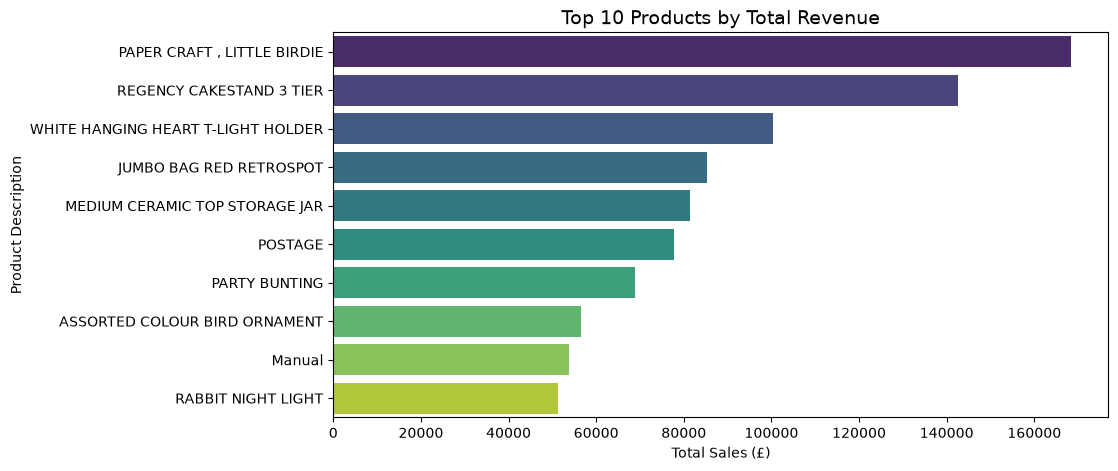

In [4]:
# Combine total revenue per product
top_products = (
    df_clean.groupby('Description')['TotalSpend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot top products
plt.figure(figsize=(10, 5))
sns.barplot(data=top_products, x='TotalSpend', y='Description', palette='viridis')
plt.title('Top 10 Products by Total Revenue', fontsize=14)
plt.xlabel('Total Sales (£)')
plt.ylabel('Product Description')
plt.show()

/tmp/ipykernel_75671/2015168126.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products_clean, x='TotalSpend', y='Description', palette='viridis')


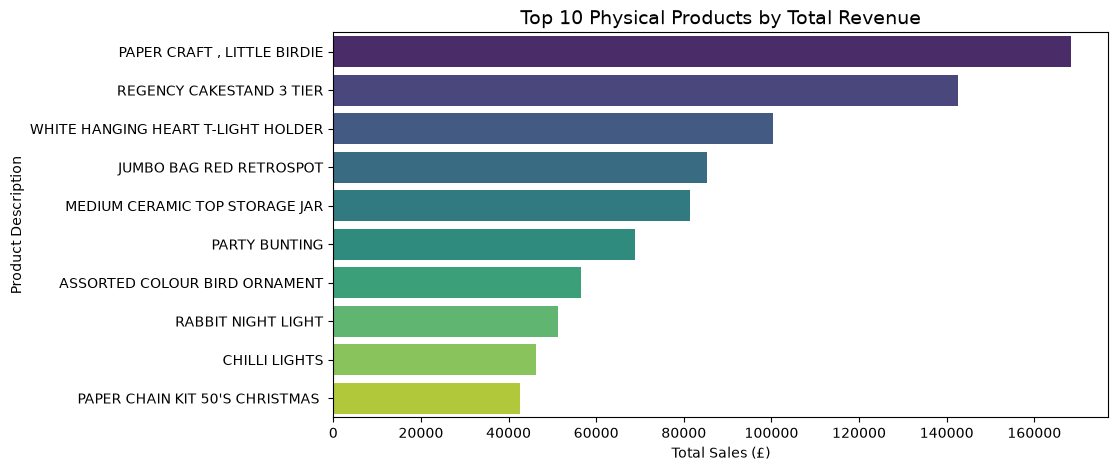

In [5]:
# Filter out non-product descriptions
non_products = ['POSTAGE', 'Manual', 'DOTCOM POSTAGE', 'CRUK Commission', 'Discount']
df_clean = df_clean[~df_clean['Description'].isin(non_products)]

# Re-aggregate top 10 true products
top_products_clean = (
    df_clean.groupby('Description')['TotalSpend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot updated clean products
plt.figure(figsize=(10, 5))
sns.barplot(data=top_products_clean, x='TotalSpend', y='Description', palette='viridis')
plt.title('Top 10 Physical Products by Total Revenue', fontsize=14)
plt.xlabel('Total Sales (£)')
plt.ylabel('Product Description')
plt.show()

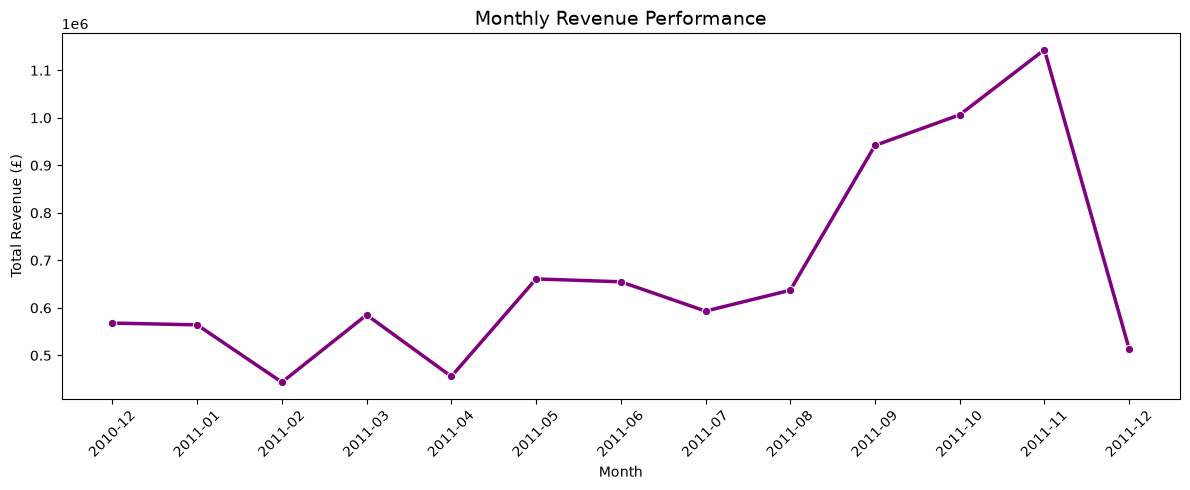

In [6]:
# Create YearMonth period and aggregate revenue
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_rev = df_clean.groupby('YearMonth')['TotalSpend'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].astype(str)

# Plot revenue line chart
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_rev, x='YearMonth', y='TotalSpend', marker='o', color='purple', linewidth=2.5)
plt.title('Monthly Revenue Performance', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_75671/3738993340.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='TotalSpend', y='Country', palette='magma')


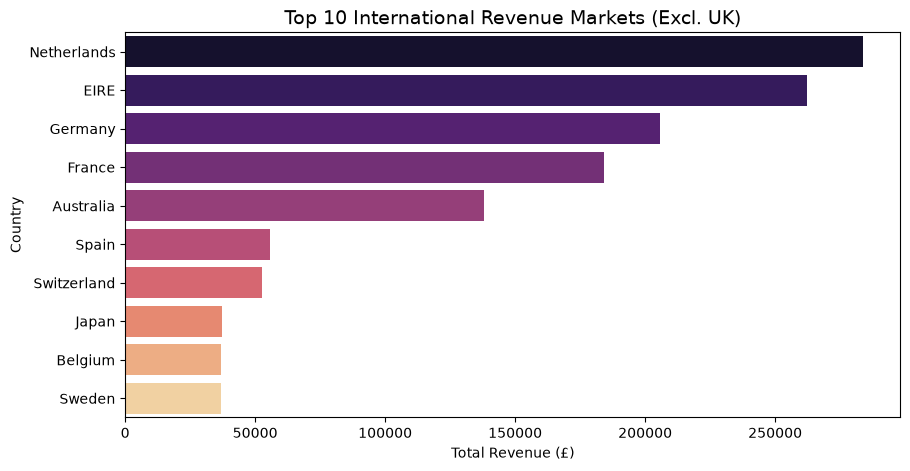

In [7]:
# Total revenue by country, excluding the United Kingdom
top_countries = (
    df_clean[df_clean['Country'] != 'United Kingdom']
    .groupby('Country')['TotalSpend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot top international markets
plt.figure(figsize=(10, 5))
sns.barplot(data=top_countries, x='TotalSpend', y='Country', palette='magma')
plt.title('Top 10 International Revenue Markets (Excl. UK)', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.show()

## 4. Customer Segmentation (RFM Analysis)
Customers are scored on a scale from 1 to 4 across three core metrics using quartile binning (`pd.qcut`):
* **Recency (R):** Days elapsed since the customer's last purchase date.
* **Frequency (F):** Total number of distinct purchase orders placed.
* **Monetary (M):** Total cumulative monetary spend.

### Defined Customer Cohorts:
* **Champions / VIP:** Recent, highly frequent, and high-spending customers.
* **Loyal Customers:** Consistent buyers across multiple billing cycles.
* **At Risk / Churned:** High historical value who have not made a purchase recently.

In [8]:
import datetime as dt

# Set snapshot date to 1 day after the latest transaction date in the dataset
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Calculate Recency, Frequency, and Monetary value per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency: Days since last purchase
    'InvoiceNo': 'nunique',                                 # Frequency: Total unique orders
    'TotalSpend': 'sum'                                     # Monetary: Total spend
}).reset_index()

# Rename columns for clarity
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# View first few customer profiles
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,19,1,1457.55
4,12350,310,1,294.40


In [9]:
# Create quartiles for Recency, Frequency, and Monetary
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Combine individual scores into an RFM Score string
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Define business labels based on R and F scores
def segment_customer(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4:
        return 'Champions / VIP'
    elif df['F_Score'] == 4:
        return 'Loyal Customers'
    elif df['R_Score'] == 4:
        return 'Recent / New Buyers'
    elif df['R_Score'] == 1:
        return 'At Risk / Churned'
    else:
        return 'Potential Satisfied'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# Check segment counts
rfm['Customer_Segment'].value_counts()

Customer_Segment
Potential Satisfied    1688
At Risk / Churned      1050
Champions / VIP         612
Recent / New Buyers     513
Loyal Customers         472
Name: count, dtype: int64

In [10]:
# Aggregate average Recency, Frequency, and Monetary spend per segment
segment_summary = rfm.groupby('Customer_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# Clean up column display
segment_summary.columns = ['Avg_Recency_Days', 'Avg_Frequency_Orders', 'Avg_Spend_GBP', 'Customer_Count']
segment_summary.sort_values(by='Avg_Spend_GBP', ascending=False)

,Avg_Recency_Days,Avg_Frequency_Orders,Avg_Spend_GBP,Customer_Count
Customer_Segment,,,,
Champions / VIP,7.67,13.59,7413.08,612
Loyal Customers,56.34,7.95,3432.41,472
Recent / New Buyers,9.50,2.57,1254.97,513
Potential Satisfied,61.88,2.08,789.00,1688
At Risk / Churned,248.84,1.45,605.12,1050


## 5. Executive Action Plan & Strategic Roadmap

### 1. Retention & Marketing Initiatives
* **VIP Loyalty Program (Champions):** Establish an exclusive tier for the **612 VIP customers** offering early access to new inventory, priority support, and custom holiday bundles to maximize Customer Lifetime Value (CLV).
* **Automated Win-Back Campaign (At-Risk):** Target the **1,050 At-Risk/Churned customers** with automated re-engagement email sequences featuring limited-time discount incentives to reactivate dormant accounts prior to peak season.
* **Nurture Workflows (Potential Satisfied):** Deploy targeted cross-sell campaigns for the **1,688 Potential Satisfied customers**, showcasing complementary products from top-performing categories.

### 2. Supply Chain & Inventory Optimization
* **Q4 Seasonal Stock Readiness:** Scale up inventory replenishment for top physical revenue drivers (*Regency Cakestand 3 Tier*, *White Hanging Heart T-Light Holder*) starting in **August/September** to meet the peak November sales surge.
* **Targeted International Logistics:** Optimize fulfillment pathways and bulk shipping schedules for primary non-UK hubs (**Netherlands**, **Ireland**, and **Germany**) to reduce lead times during high-volume periods.

### 3. Key Takeaways & Analytical Summary
* **Data Hygiene Impact:** Removing guest checkout rows (~25% missing CustomerIDs) and administrative fee codes (`POSTAGE`, `Manual`) ensured customer cohort modeling was built on genuine physical product purchases.
* **Behavioral Segmentation:** Applying quantile-based RFM scoring provided a clear framework to transition raw transactional logs into targeted commercial strategy.